# Somas de Riemann

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Definição

Uma [soma de Riemann](https://en.wikipedia.org/wiki/Riemann_sum) de uma função $f(x)$ sobre uma partição

$$
x_0 = a < x_1 < \cdots < x_{N-1} < x_N = b
$$

é uma soma da forma

$$
\sum_{i=1}^N f(x_i^ * ) (x_i - x_{i-1}) \ \ , \ x_i^* \in [x_{i-1},x_i]
$$

onde cada valor $x_i^* \in [x_{i-1},x_i]$ em cada subintervalo é arbitrário.

As somas de Riemann são importantes porque fornecem uma maneira fácil de aproximar uma integral definida

$$
\int_a^b f(x) \, dx \approx \sum_{i=1}^N f(x_i^ * ) (x_i - x_{i-1}) \ \ , \ x_i^* \in [x_{i-1},x_i]
$$

Note que o produto $f(x_i^ * ) (x_i - x_{i-1})$ para cada $i$ é a área de um retângulo de altura $f(x_i^ * )$ e largura $x_i - x_{i-1}$. Podemos pensar em uma soma de Riemann como a área de $N$ retângulos com alturas determinadas pelo gráfico de $y=f(x)$.

O valor $x_i^*$ escolhido em cada subintervalo é arbitrário, no entanto, existem certas escolhas óbvias:

* Uma *soma de Riemann à esquerda* é quando cada $x_i^* = x_{i-1}$ é a extremidade esquerda do subintervalo $[x_{i-1},x_i]$
* Uma *soma de Riemann à direita* é quando cada $x_i^* = x_i$ é a extremidade direita do subintervalo $[x_{i-1},x_i]$
* Uma *soma de Riemann pelo ponto médio* é quando cada $x_i^* = (x_{i-1} + x_i)/2$ é o ponto médio do subintervalo $[x_{i-1},x_i]$

Vamos visualizar os retângulos nas somas de Riemann à esquerda, à direita e pelo ponto médio para a função

$$
f(x) = \frac{1}{1 + x^2}
$$

no intervalo $[0,5]$ com uma partição de tamanho $N=10$.

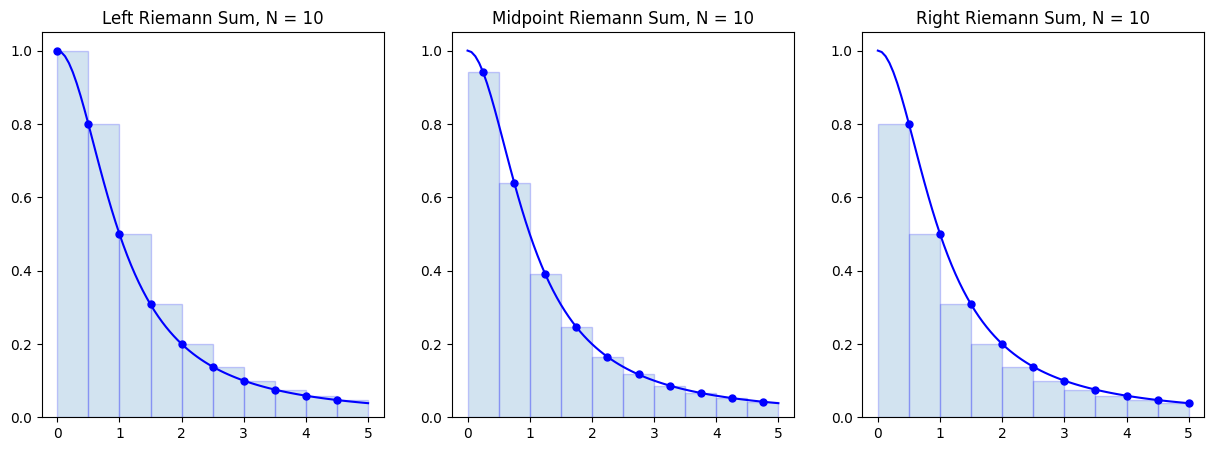

In [4]:
f = lambda x : 1/(1+x**2)
a = 0; b = 5; N = 10
n = 8 # Use n*N+1 points to plot the function smoothly

x = np.linspace(a,b,N+1)
y = f(x)

X = np.linspace(a,b,n*N+1)
Y = f(X)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(X,Y,'b')
x_left = x[:-1] # Left endpoints
y_left = y[:-1]
plt.plot(x_left,y_left,'b.',markersize=10)
plt.bar(x_left,y_left,width=(b-a)/N,alpha=0.2,align='edge',edgecolor='b')
plt.title('Left Riemann Sum, N = {}'.format(N))

plt.subplot(1,3,2)
plt.plot(X,Y,'b')
x_mid = (x[:-1] + x[1:])/2 # Midpoints
y_mid = f(x_mid)
plt.plot(x_mid,y_mid,'b.',markersize=10)
plt.bar(x_mid,y_mid,width=(b-a)/N,alpha=0.2,edgecolor='b')
plt.title('Midpoint Riemann Sum, N = {}'.format(N))

plt.subplot(1,3,3)
plt.plot(X,Y,'b')
x_right = x[1:] # Left endpoints
y_right = y[1:]
plt.plot(x_right,y_right,'b.',markersize=10)
plt.bar(x_right,y_right,width=-(b-a)/N,alpha=0.2,align='edge',edgecolor='b')
plt.title('Right Riemann Sum, N = {}'.format(N))

plt.show()

Note que quando a função $f(x)$ é decrescente em $[a,b]$, as extremidades esquerdas fornecem uma superestimação da integral $\int_a^b f(x) dx$ e as extremidades direitas fornecem uma subestimação. O oposto é verdadeiro quando a função é crescente.

Vamos calcular o valor de cada uma das somas de Riemann:

In [5]:
N = 100
dx = (b-a)/N
x_left = np.linspace(a,b-dx,N)
x_midpoint = np.linspace(dx/2,b - dx/2,N)
x_right = np.linspace(dx,b,N)

print("Partition with",N,"subintervals.")
left_riemann_sum = np.sum(f(x_left) * dx)
print("Left Riemann Sum:",left_riemann_sum)

midpoint_riemann_sum = np.sum(f(x_midpoint) * dx)
print("Midpoint Riemann Sum:",midpoint_riemann_sum)

right_riemann_sum = np.sum(f(x_right) * dx)
print("Right Riemann Sum:",right_riemann_sum)

Partition with 100 subintervals.
Left Riemann Sum: 1.3974361466841385
Midpoint Riemann Sum: 1.3734023078241722
Right Riemann Sum: 1.3493592236072154


Nós sabemos o valor exato

$$
\int_0^5 \frac{1}{1 + x^2} dx = \arctan(5)
$$

e podemos comparar as somas de Riemann com o valor

In [6]:
I = np.arctan(5)
print(I)

1.373400766945016


In [7]:
print("Left Riemann Sum Error:",np.abs(left_riemann_sum - I))
print("Midpoint Riemann Sum:",np.abs(midpoint_riemann_sum - I))
print("Right Riemann Sum:",np.abs(right_riemann_sum - I))

Left Riemann Sum Error: 0.02403537973912262
Midpoint Riemann Sum: 1.540879156269881e-06
Right Riemann Sum: 0.02404154333780051


## Fórmulas de Erro

Uma soma de Riemann é uma aproximação de uma integral definida. Uma pergunta natural surge: quão boa é a aproximação de uma soma de Riemann?

---

**Teorema.** Seja $L_N(f)$ a soma de Riemann à esquerda

$$
L_N(f) = \sum_{i=1}^N f(x_{i-1} ) \Delta x
$$

onde $\Delta x = (b-a)/N$ e $x_i = a + i \Delta x$. O limite do erro é

$$
E_N^{L}(f) = \left| \ \int_a^b f(x) \ dx - L_N(f) \ \right| \leq \frac{(b-a)^2}{2 N} K_1
= \frac{(b-a)}{2} K_1 \Delta x
$$

onde $\left| \, f'(x) \, \right| \leq K_1$ para todo $x \in [a,b]$.

---

**Teorema.** Seja $R_N(f)$ a soma de Riemann à direita

$$
R_N(f) = \sum_{i=1}^N f(x_{i} ) \Delta x
$$

onde $\Delta x = (b-a)/N$ e $x_i = a + i \Delta x$. O limite do erro é

$$
E_N^{R}(f) = \left| \ \int_a^b f(x) \ dx - R_N(f) \ \right| \leq \frac{(b-a)^2}{2 N} K_1
$$

onde $\left| \, f'(x) \, \right| \leq K_1$ para todo $x \in [a,b]$.

---

**Teorema.** Seja $M_N(f)$ a soma de Riemann pelo ponto médio

$$
M_N(f) = \sum_{i=1}^N f(x_i^* ) \Delta x
$$

onde $\Delta x = (b-a)/N$ e $x_i^* = (x_{i-1} + x_i)/2$ para $x_i = a + i \Delta x$. O limite do erro é


$$
E_N^{M}(f) = \left| \ \int_a^b f(x) \ dx - M_N(f) \ \right| \leq \frac{(b-a)^3}{24 N^2} K_2
=
\frac{(b-a)}{24}K_2 \Delta x^2
$$

onde $\left| \, f''(x) \, \right| \leq K_2$ para todo $x \in [a,b]$.

---

Há vários pontos a serem observados:

* As somas de Riemann à esquerda e à direita têm o mesmo limite de erro, que depende da primeira derivada $f'(x)$.
* O limite de erro da soma de Riemann pelo ponto médio depende da segunda derivada $f''(x)$.
* Esperamos que a soma de Riemann pelo ponto médio forneça uma aproximação melhor à medida que $N \to \infty$, pois seu limite de erro é inversamente proporcional a $N^2$, enquanto o limite de erro das somas de Riemann à esquerda/direita é inversamente proporcional apenas a $N$.

## Implementação

Vamos escrever uma função chamada `riemann_sum` que recebe 5 parâmetros de entrada `f`, `a`, `b`, `N` e `method` e retorna a soma de Riemann

$$
\sum_{i=1}^N f(x_i^*) \Delta x
$$

onde $\Delta x = (b-a)/N$ e $x_i = a + i\Delta x$ define uma partição com $N$ subintervalos de *comprimento igual*, e `method` determina se usamos as extremidades *esquerdas*, *direitas* ou os *pontos médios* (com pontos médios como o método padrão).

In [8]:
def riemann_sum(f,a,b,N,method='midpoint'):
    '''Compute the Riemann sum of f(x) over the interval [a,b].

    Parameters
    ----------
    f : function
        Vectorized function of one variable
    a , b : numbers
        Endpoints of the interval [a,b]
    N : integer
        Number of subintervals of equal length in the partition of [a,b]
    method : string
        Determines the kind of Riemann sum:
        right : Riemann sum using right endpoints
        left : Riemann sum using left endpoints
        midpoint (default) : Riemann sum using midpoints

    Returns
    -------
    float
        Approximation of the integral given by the Riemann sum.
    '''
    dx = (b - a)/N
    x = np.linspace(a,b,N+1)

    if method == 'left':
        x_left = x[:-1]
        return np.sum(f(x_left)*dx)
    elif method == 'right':
        x_right = x[1:]
        return np.sum(f(x_right)*dx)
    elif method == 'midpoint':
        x_mid = (x[:-1] + x[1:])/2
        return np.sum(f(x_mid)*dx)
    else:
        raise ValueError("Method must be 'left', 'right' or 'midpoint'.")

Vamos testar nossa função com entradas para as quais sabemos exatamente qual deve ser a saída. Por exemplo, sabemos que

$$
\int_0^{\pi/2} \sin(x) \, dx = 1
$$

e, como $\sin(x)$ é crescente em $[0,\pi/2]$, sabemos que as extremidades esquerdas darão uma subestimação e as extremidades direitas darão uma superestimação.

In [9]:
print(riemann_sum(np.sin,0,np.pi/2,100))
print(riemann_sum(np.sin,0,np.pi/2,1000))

1.0000102809119054
1.0000001028083867


In [10]:
print(riemann_sum(np.sin,0,np.pi/2,100,'right'))
print(riemann_sum(np.sin,0,np.pi/2,1000,'right'))

1.007833419873582
1.0007851925466307


In [11]:
print(riemann_sum(np.sin,0,np.pi/2,100,'left'))
print(riemann_sum(np.sin,0,np.pi/2,1000,'left'))

0.992125456605633
0.9992143962198358


Também sabemos que $\int_0^1 x \, dx = 1/2$ e o ponto médio deve dar o resultado exato para qualquer $N$:

In [12]:
riemann_sum(lambda x : x,0,1,1)

np.float64(0.5)

## Exemplos

### Aproximar Pi

Encontre um valor $N$ que garanta que a soma de Riemann à direita de $f(x)=\frac{4}{1 + x^2}$ sobre $[0,1]$ esteja a menos de $10^{-5}$ do valor exato

$$
\int_0^1 \frac{4}{1 + x^2} dx = \pi
$$

Calcule

$$
f'(x) = -\frac{8x}{(1+x^2)^2}
$$

Use otimização por força bruta para encontrar um limitante para $\left| f'(x) \right|$ em $[0,1]$:

In [13]:
x = np.linspace(0,1,1000)
y = np.abs(-8*x/(1 + x**2)**2)
np.max(y)

np.float64(2.5980759093919907)

Portanto, $\left| f'(x) \right| \leq 2.6$ para $x \in [0,1]$. Use o limite de erro

$$
\frac{(b-a)^2}{2 N} K_1 \leq 10^{-5} \ \Rightarrow \ \frac{1.3}{N} \leq 10^{-5} \ \Rightarrow \ 130000 \leq N
$$

Vamos calcular a soma de Riemann à direita para $N=130000$:

In [14]:
approximation = riemann_sum(lambda x : 4/(1 + x**2),0,1,130000,method='right')
print(approximation)

3.1415849612722386


Verifique a precisão da aproximação

In [15]:
np.abs(approximation - np.pi) < 10**(-5)

np.True_

E para o método do ponto médio? A estimativa de erro é

$$
E_N^{M}(f) \leq \frac{(b-a)^3}{24 N^2} K_2
=
\frac{(b-a)}{24}K_2 \Delta x^2
$$

In [16]:
y2 = np.abs((24*x**2-8)/(1 + x**2)**3)
np.max(y2)

np.float64(8.0)

Portanto, $\left| f''(x) \right| \leq 8$ para $x \in [0,1]$. Use o limite de erro

$$
\frac{(b-a)^3}{24 N^2} K_2 \leq 10^{-5} \ \Rightarrow \ \frac{1}{3N^2} \leq 10^{-5} \ \Rightarrow \ \frac{100000}{3} \leq N^2
\Rightarrow \ 182.7 \leq N
$$

Vamos calcular a soma de Riemann à direita para $N=183$:

In [17]:
(100000/3)**(1/2)

182.57418583505537

In [18]:
approximation = riemann_sum(lambda x : 4/(1 + x**2),0,1,183)
print(approximation)

3.141595141969062


In [19]:
np.abs(approximation - np.pi) < 10**(-5)

np.True_

### Aproximar ln(2)

Encontre um valor $N$ que garanta que a soma de Riemann pelo ponto médio de $f(x)=\frac{1}{x}$ sobre $[1,2]$ esteja a menos de $10^{-8}$ do valor exato

$$
\int_1^2 \frac{1}{x} dx = \ln(2)
$$

Calcule

$$
f''(x) = \frac{2}{x^3}
$$

Como $f''(x)$ é decrescente para todo $x>0$, temos $\left| \, f''(x) \, \right| \leq 2$ para todo $x \in [1,2]$. Use o limite de erro:

$$
\frac{(b-a)^3}{24 N^2} K_2 \leq 10^{-8} \ \Rightarrow \ \frac{1}{12 N^2} \leq 10^{-8} \ \Rightarrow \frac{10^4}{\sqrt{12}} \leq N
$$

In [20]:
10**4 / np.sqrt(12)

np.float64(2886.751345948129)

Portanto, uma partição de tamanho $N=2887$ garante a precisão desejada:

In [21]:
approximation = riemann_sum(lambda x : 1/x,1,2,2887,method='midpoint')
print(approximation)

0.6931471768105913


Verifique a precisão da aproximação:

In [22]:
np.abs(approximation - np.log(2)) < 10**(-8)

np.True_

## Exercícios

**Exercício 1.** Considere a integral

$$
\int_1^2 \frac{dx}{1+x^3}
$$

Sem plotar as funções $f(x)$, $f'(x)$ ou $f''(x)$, encontre um valor $N$ tal que $E_N^R(f) \leq 10^{-5}$ dado

$$
f(x) = \frac{1}{1 + x^3} \ , \ f'(x) = -\frac{3 x^{2}}{\left(x^{3} + 1\right)^{2}} \ , \ f''(x) = \frac{6 x \left(2 x^{3} - 1\right)}{\left(x + 1\right)^{3} \left(x^{2} - x + 1\right)^{3}} \\\\
$$

**Exercício 2.** Plote a função $f''(x)$ da questão anterior no intervalo $[1,2]$ e encontre um valor $N$ tal que $E_N^M(f) \leq 10^{-5}$ para a integral na questão anterior.

**Exercício 3.** Seja $f(x) = x^x$ e note que

$$
f'(x) = x^{x} \left(\log{\left(x \right)} + 1\right) \ , \ f''(x) = x^{x} \left(\log{\left(x \right)} + 1\right)^{2} + x^{x-1}
$$

Plote a função $f''(x)$ e use essa informação para calcular $T_N(f)$ para a integral

$$
\int_1^2 x^x \, dx
$$

tal que $E_N^T(f) \leq 10^{-3}$.